In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Path where your CSVs are stored
DATA_DIR = "/home/paul/Msci/dm_sets_multiclass/run3/"
OUTPUT_DIR = "/home/paul/Msci/plots/"

In [16]:
#file_mapping = [
   # ("run1_NuMI_nu_overlay_larcv_cropped_scores_multiclass.csv", "In cryo"),
   # ("run1_NuMI_dirt_larcv_cropped_scores_multiclass.csv", "Out of cryo"),
    #("run1_offbeam_larcv_cropped_full_set_scores_multiclass.csv", "Beam-off"),
    #("run1_dt_ratio_0.6_ma_0.05_pi0_larcv_cropped_scores_multiclass.csv", "Dark Trident"),
#]
file_mapping = [
    ("run3_nu_overlay_larcv_cropped_scores_multiclass.csv", "In cryo"),
    ("run3_dirt_larcv_cropped_scores_multiclass.csv", "Out of cryo"),
    ("run3_offbeam_larcv_cropped_scores_multiclass.csv", "Beam-off"),
    ("run3_dt_ratio_0.6_ma_0.05_pi0_larcv_cropped_scores_multiclass.csv", "Dark Trident"),
]


CLASS_NAMES = ["NCπ0", "Cosmics", "DM Signal"]

dfs = []
for filename, label in file_mapping:
    path = os.path.join(DATA_DIR, filename)
    df = pd.read_csv(path)
    df["true_label"] = label
    dfs.append(df)
    print(f"Loaded {label}: {len(df)} events")

full_df = pd.concat(dfs, ignore_index=True)

Loaded In cryo: 11526 events
Loaded Out of cryo: 2413 events
Loaded Beam-off: 15479 events
Loaded Dark Trident: 12086 events


In [17]:
true_labels = ["In cryo", "Out of cryo", "Beam-off", "Dark Trident"]
cm = np.zeros((4, 3), dtype=int)

for i, true_label in enumerate(true_labels):
    subset = full_df[full_df['true_label'] == true_label]
    for j in range(3):
        cm[i, j] = (subset['pred_class'] == j).sum()

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 8319  1353  1853]
 [ 1582   655   175]
 [10440  4295   702]
 [  586   145 11354]]


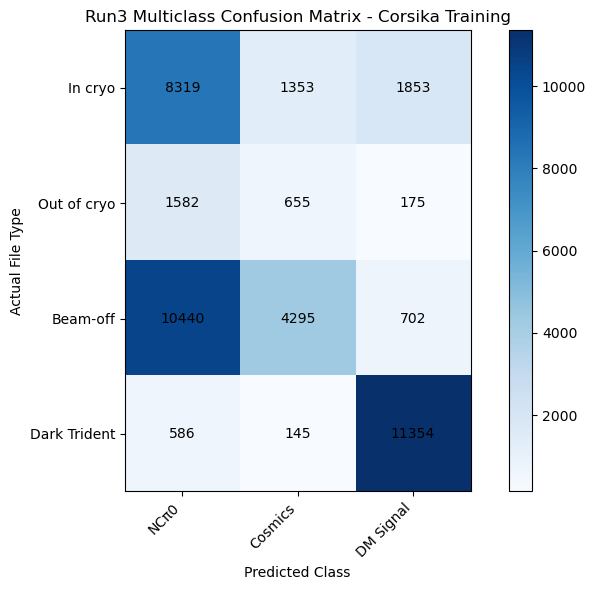

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)

ax.set_xticks(range(3))
ax.set_yticks(range(4))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(true_labels)
ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual File Type")
ax.set_title("Run3 Multiclass Confusion Matrix - Corsika Training")

# Annotate
for i in range(4):
    for j in range(3):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center")

plt.tight_layout()
os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.savefig(os.path.join(OUTPUT_DIR, "run3_confusion_matrix_corsika.png"), dpi=300)
plt.savefig(os.path.join(OUTPUT_DIR, "run3_confusion_matrix_corsika.pdf"))
plt.show()

In [19]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# Get predictions
y_true_numeric = full_df['true_class'].values
y_pred_numeric = full_df['pred_class'].values

# Calculate metrics
precision, recall, f1, support = precision_recall_fscore_support(
    y_true_numeric, y_pred_numeric, labels=[0,1,2,3], zero_division=0
)

print("="*70)
print("Classification Performance by Class")
print("="*70)
for i, label in enumerate(true_labels):
    print(f"\n{label}:")
    print(f"  Precision: {precision[i]:.3f} (of predictions, how many were correct)")
    print(f"  Recall:    {recall[i]:.3f} (of true events, how many were found)")
    print(f"  F1-score:  {f1[i]:.3f} (harmonic mean of precision & recall)")
    print(f"  Support:   {support[i]} events")

overall_acc = accuracy_score(y_true_numeric, y_pred_numeric)
print(f"\nOverall Accuracy: {overall_acc:.3f}")

Classification Performance by Class

In cryo:
  Precision: 1.000 (of predictions, how many were correct)
  Recall:    0.505 (of true events, how many were found)
  F1-score:  0.671 (harmonic mean of precision & recall)
  Support:   41459 events

Out of cryo:
  Precision: 0.000 (of predictions, how many were correct)
  Recall:    0.000 (of true events, how many were found)
  F1-score:  0.000 (harmonic mean of precision & recall)
  Support:   0 events

Beam-off:
  Precision: 0.000 (of predictions, how many were correct)
  Recall:    0.000 (of true events, how many were found)
  F1-score:  0.000 (harmonic mean of precision & recall)
  Support:   0 events

Dark Trident:
  Precision: 0.000 (of predictions, how many were correct)
  Recall:    0.000 (of true events, how many were found)
  F1-score:  0.000 (harmonic mean of precision & recall)
  Support:   0 events

Overall Accuracy: 0.505


In [23]:
# Cell: Check the raw values and softmax
print("Checking raw p0, p1, p2 values:")
print(full_df[['p0', 'p1', 'p2']].describe())

print("\n" + "="*70)
print("Sample of raw values:")
print(full_df[['p0', 'p1', 'p2', 'pred_class', 'true_label']].head(20))

# Check if these are already probabilities or logits
print("\n" + "="*70)
print("Do p0, p1, p2 sum to 1?")
row_sums = full_df[['p0', 'p1', 'p2']].sum(axis=1)
print(f"Min sum: {row_sums.min()}")
print(f"Max sum: {row_sums.max()}")
print(f"Mean sum: {row_sums.mean()}")

if np.allclose(row_sums, 1.0, atol=0.01):
    print("✓ YES - These are already probabilities (sum to 1)")
    print("   → No need for softmax!")
else:
    print("✗ NO - These might be logits")
    print("   → Need softmax conversion")

Checking raw p0, p1, p2 values:
                 p0            p1            p2
count  41504.000000  41504.000000  41504.000000
mean      -0.602356     -0.917634     -0.730540
std       32.895725     32.884092     32.891762
min     -999.000000   -999.000000   -999.000000
25%        0.017198      0.000379      0.007233
50%        0.484512      0.008907      0.055188
75%        0.929552      0.157077      0.957127
max        0.999978      0.999998      1.000000

Sample of raw values:
          p0        p1        p2  pred_class true_label
0   0.161260  0.000997  0.837743           2    In cryo
1   0.985074  0.000083  0.014843           0    In cryo
2   0.978768  0.018289  0.002942           0    In cryo
3   0.801189  0.005592  0.193218           0    In cryo
4   0.744078  0.175314  0.080608           0    In cryo
5   0.999487  0.000172  0.000340           0    In cryo
6   0.654970  0.327363  0.017667           0    In cryo
7   0.975984  0.019716  0.004300           0    In cryo
8   0.997

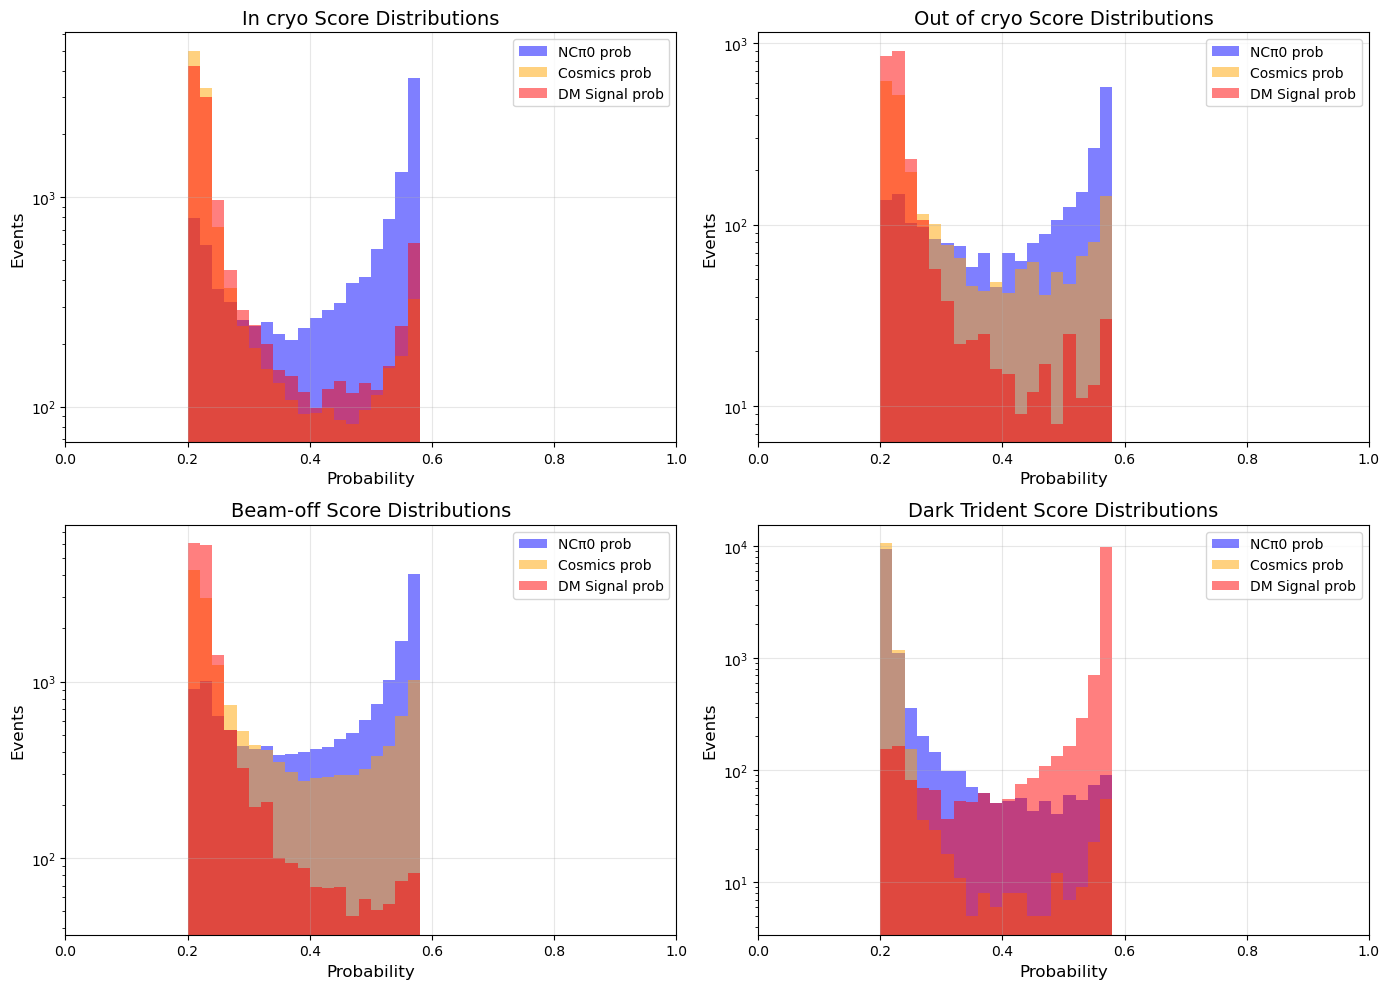


Score distribution plot saved!


In [22]:
from scipy.special import softmax

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (filename, label) in enumerate(file_mapping):
    ax = axes[idx]
    df_class = dfs[idx]
    
    # Convert logits to probabilities using softmax
    logits = df_class[['p0', 'p1', 'p2']].values
    probs = softmax(logits, axis=1)
    
    # Plot the three probability distributions
    ax.hist(probs[:, 0], bins=50, alpha=0.5, label='NCπ0 prob', color='blue', range=(0,1))
    ax.hist(probs[:, 1], bins=50, alpha=0.5, label='Cosmics prob', color='orange', range=(0,1))
    ax.hist(probs[:, 2], bins=50, alpha=0.5, label='DM Signal prob', color='red', range=(0,1))
    
    ax.set_xlabel('Probability', fontsize=12)
    ax.set_ylabel('Events', fontsize=12)
    ax.set_title(f'{label} Score Distributions', fontsize=14)
    ax.legend(fontsize=10)
    ax.set_yscale('log')
    ax.set_xlim(0, 1)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "run3_score_distributions_by_class.png"), dpi=300)
plt.savefig(os.path.join(OUTPUT_DIR, "run3_score_distributions_by_class.pdf"))
plt.show()

print("\nScore distribution plot saved!")